<a href="https://colab.research.google.com/github/ongsoony8382/financial-data-programming/blob/main/%ED%99%98%EC%9C%A8%EA%B3%BC_%EC%A3%BC%EA%B0%80%EC%9D%98_%EC%83%81%EA%B4%80%EA%B4%80%EA%B3%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 라이브러리 설치 및 환경 설정
금융 데이터 수집을 위해 야후 파이낸스(yfinance)와 연준 경제 데이터(pandas_datareader) 라이브러리를 사용.

In [10]:
# [Colab Cell 1]
# 라이브러리 설치
!pip install yfinance pandas_datareader

import pandas as pd
import pandas_datareader.data as web
import yfinance as yf
import matplotlib.pyplot as plt
import datetime

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8')

# 데이터 수집 (Data Acquisition)
가장 중요한 **원/달러 환율**과 한국 경제의 대표 지표인 **코스피(KOSPI)** 지수를 가져옴.

# 원/달러 환율 (From FRED) 가져오기
미국 연방준비위원회(FRED) 데이터베이스는 거시경제 데이터를 얻기에 가장 좋음.
- DEXKOUS: South Korea / U.S. Foreign Exchange Rate

In [11]:
# 기간 설정 (2010년부터 현재까지)
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime.now()

# FRED에서 원/달러 환율 데이터 가져오기
# df_exchange : 데이터 프레임 환율

df_exchange = web.DataReader('DEXKOUS', 'fred', start='2010-01-01', end='2021-12-31')
#df_exchange = web.DataReader('DEXKOUS', 'fred', start='2022-01-01')
df_exchange.columns = ['KRW_USD'] # 컬럼명 변경

print(f"환율 데이터 수: {df_exchange.shape}")
df_exchange.tail()

환율 데이터 수: (3131, 1)


,KRW_USD
DATE,
2021-12-27,1186.82
2021-12-28,1188.15
2021-12-29,1185.51
2021-12-30,1188.59
2021-12-31,NaN


# 코스피 지수 (From Yahoo Finance) 가져오기
- ^KS11: KOSPI Composite Index

In [12]:
# 야후 파이낸스에서 코스피 지수 가져오기
kospi = yf.download('^KS11', start='2010-01-01', end='2021-12-31')
#kospi = yf.download('^KS11', start='2022-01-01')

# 종가(Adj Close)만 추출하여 데이터프레임 만들기
df_kospi = kospi[['Close']].copy()
df_kospi.columns = ['KOSPI']

print(f"코스피 데이터 수: {df_kospi.shape}")
df_kospi.tail()

/tmp/ipykernel_4375/2196732038.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  kospi = yf.download('^KS11', start='2010-01-01', end='2021-12-31')
[*********************100%***********************]  1 of 1 completed

코스피 데이터 수: (2959, 1)


,KOSPI
Date,
2021-12-24,3012.429932
2021-12-27,2999.550049
2021-12-28,3020.239990
2021-12-29,2993.290039
2021-12-30,2977.649902


# 데이터 전처리 및 병합 (Merge)
- 두 데이터는 휴장일 등이 달라 날짜가 정확히 일치하지 않을 수 있음. 이를 하나로 합치기


In [14]:
# 날짜 인덱스를 기준으로 inner join
df_inner = pd.merge(df_exchange, df_kospi,
                    left_index=True, right_index=True,
                    how='inner')

# 날짜 인덱스를 기준으로 outer join
df_outer = pd.merge(df_exchange, df_kospi,
                    left_index=True, right_index=True,
                    how='outer')

# 각각 엑셀로 저장
df_inner.to_excel('output_file_inner.xlsx', index=True)
df_outer.to_excel('output_file_outer.xlsx', index=True)

print(f"Inner 데이터 수: {df_inner.shape}")
print(f"Outer 데이터 수: {df_outer.shape}")

print("Inner 데이터 샘플:")
print(df_inner.tail(10))

print("Outer 데이터 샘플:")
print(df_outer.tail(10))

Inner 데이터 수: (2959, 2)
Outer 데이터 수: (3131, 2)
Inner 데이터 샘플:
            KRW_USD        KOSPI
2021-12-17  1181.03  3017.729980
2021-12-20  1191.07  2963.000000
2021-12-21  1192.35  2975.030029
2021-12-22  1190.21  2984.479980
2021-12-23  1187.59  2998.169922
2021-12-24      NaN  3012.429932
2021-12-27  1186.82  2999.550049
2021-12-28  1188.15  3020.239990
2021-12-29  1185.51  2993.290039
2021-12-30  1188.59  2977.649902
Outer 데이터 샘플:
            KRW_USD        KOSPI
2021-12-20  1191.07  2963.000000
2021-12-21  1192.35  2975.030029
2021-12-22  1190.21  2984.479980
2021-12-23  1187.59  2998.169922
2021-12-24      NaN  3012.429932
2021-12-27  1186.82  2999.550049
2021-12-28  1188.15  3020.239990
2021-12-29  1185.51  2993.290039
2021-12-30  1188.59  2977.649902
2021-12-31      NaN          NaN


# 데이터 시각화: 이중축 그래프 (Dual Axis)
- 환율과 코스피지수는 단위가 비슷해 보이지만 변동 폭이 다름.
- 이를 하나의 그래프에 겹쳐 보기 위해 축을 2개(왼쪽, 오른쪽) 사용.

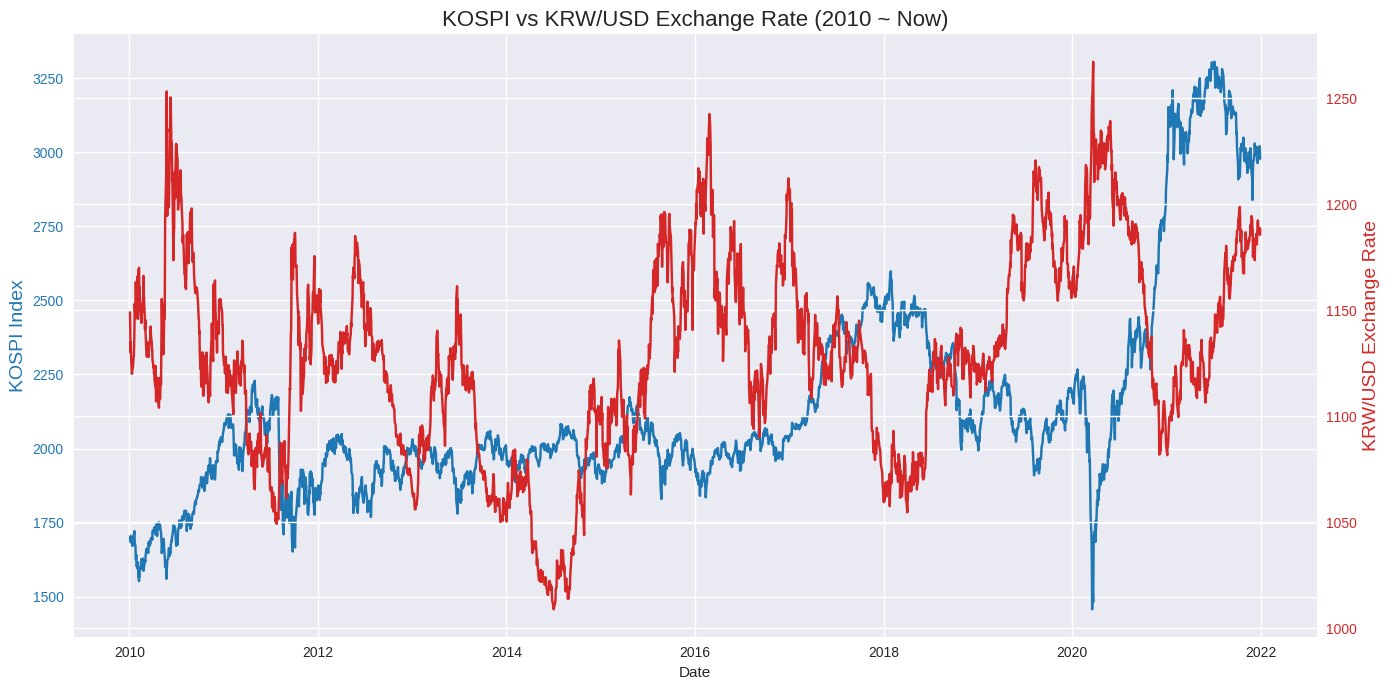

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# 첫 번째 축 (왼쪽): 코스피 (파란색)
color_1 = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('KOSPI Index', color=color_1, fontsize=14)
ax1.plot(df_merge.index, df_merge['KOSPI'], color=color_1, label='KOSPI')
ax1.tick_params(axis='y', labelcolor=color_1)

# 두 번째 축 (오른쪽): 환율 (빨간색) - twinx() 사용
ax2 = ax1.twinx()
color_2 = 'tab:red'
ax2.set_ylabel('KRW/USD Exchange Rate', color=color_2, fontsize=14)
ax2.plot(df_merge.index, df_merge['KRW_USD'], color=color_2, label='KRW/USD')
ax2.tick_params(axis='y', labelcolor=color_2)

# 제목 및 그리드
plt.title('KOSPI vs KRW/USD Exchange Rate (2010 ~ Now)', fontsize=16)
fig.tight_layout() # 레이아웃 조정
plt.show()

# 결과 분석
- 2021년까지의 그래프를 보면 데칼코마니처럼 반대로 움직이는 경향이 보임.

- 환율 상승(원화 가치 하락) 📈 ⮕ 외국인 자금 이탈 우려 ⮕ 주가 하락 📉
- 환율 하락(원화 가치 상승) 📉 ⮕ 외국인 자금 유입 기대 ⮕ 주가 상승 📈
- 2022년부터는 반대로 움직이는 경향이 뚜렷하지 않음.